In [7]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from glob import glob
from os import path

import matplotlib.pyplot as plt
import matplotlib.font_manager as font_manager

font_path = font_manager.findfont(font_manager.FontProperties(family='Arial'))
plt.rcParams['font.family'] = 'Arial'
plt.rcParams['font.sans-serif'] = [font_path]
plt.rcParams['svg.fonttype'] = 'none'


In [8]:
# just isolating intermolecular base pairing, in R1285o's check out the precision recall, f1

native_interaction_labels = pd.read_csv('interaction_results.csv')
predicted_intermolecular_interactions = pd.read_csv('all_intermolecular_interactions.csv')
native_interactions = set(tuple(sorted((row['interaction_type'], row['residue']))) for _, row in native_interaction_labels.iterrows())
predicted_intermolecular_interactions['in_native'] = predicted_intermolecular_interactions.apply(lambda row: tuple(sorted((row['interaction_type'], row['interaction_details']))) in native_interactions, axis=1)

positive_interactions = len(native_interaction_labels[(native_interaction_labels.interaction_type=='base_pairs') & (native_interaction_labels.residue.str.contains('0:'))&(native_interaction_labels.residue.str.contains('1:'))].residue.unique())



def calculate_f1_by_prediction(df, total_positives):
    
    #Group by prediction and count true positives and false positives
    grouped = df.groupby('prediction')['in_native'].agg(['sum', 'count']) #sum is TP, count is TP + FP



    # Calculate precision and recall
    grouped['precision'] = grouped['sum'] / grouped['count']
    grouped['recall'] = grouped['sum'] / total_positives


    #Calculate F1-score
    grouped['f1_score'] = 2 * (grouped['precision'] * grouped['recall']) / (grouped['precision'] + grouped['recall'])
    grouped['f1_score'] = grouped['f1_score'].fillna(0) #Handle cases where precision or recall is zero

    return grouped.sort_values(by='f1_score') #return only the f1 score


# Example usage
intermolecular_f1 = calculate_f1_by_prediction(predicted_intermolecular_interactions[predicted_intermolecular_interactions.interaction_type=='base_pairs'],positive_interactions)

<Axes: xlabel='recall', ylabel='precision'>

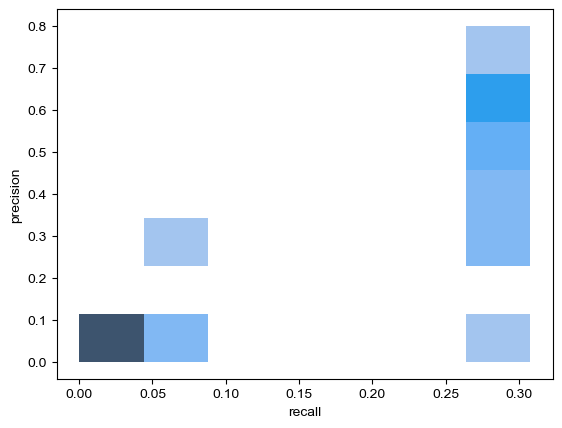

In [9]:
sns.histplot(intermolecular_f1,x='recall',y='precision')

In [13]:
# for kink turn, could also isolate to just the three bp of interest
# for rpsu
base_pairs_needed = ['0:140 0:160','0:141 0:156',# '0:139 0:161', '0:142 0:155', 
                     '1:140 1:160','1:141 1:156']#'1:139 1:161',,'1:142 1:155']
nt_unpaired_needed = ['0:159','0:158','0:157',
                      '1:159','1:158','1:157']


# native_interaction_labels[(native_interaction_labels.motif=='kink') & (native_interaction_labels.prediction=='R1285TS156_3o.pdb')]
# 71 72 73
# 0:71 0:178 S H T   0:72 0:177 H S T   0:73 0:176 H S T
kink_base_pairs = ['0:71 0:178','0:72 0:177','0:73 0:176']
def check_base_pairs_and_unpaired(filepath, base_pairs_needed, nt_unpaired_needed):
    with open(filepath, 'r') as f:
        file_content = f.read()

    base_pairs_found = 0
    unpaired_found = 0

    for pair in base_pairs_needed:
        if pair in file_content:
            base_pairs_found += 1

    for unpaired in nt_unpaired_needed:
        if unpaired in file_content:
            unpaired_found += 1

    total_base_pairs = len(base_pairs_needed)
    total_unpaired = len(nt_unpaired_needed)

    results = {
        'prediction':path.split(filepath.split('.base_pairs')[0])[1],
        'base_pairs_correct': base_pairs_found,
        'base_pairs_percent': (base_pairs_found / total_base_pairs) * 100 if total_base_pairs > 0 else 0,
        'unpaired_correct': total_unpaired-unpaired_found,
        'unpaired_percent': ((total_unpaired-unpaired_found) / total_unpaired) * 100 if total_unpaired > 0 else 0,
    }

    return (total_unpaired-unpaired_found+base_pairs_found) / (total_base_pairs+total_unpaired) * 100, results


rpsu = []
rpsu_full = []
kink = []
kink_full = []
for filepath in glob('R1285o/*.base_pairs.txt'):
    rpsu.append({'prediction':path.split(filepath.split('.base_pairs')[0])[1],
                 'rpsu': check_base_pairs_and_unpaired(filepath, base_pairs_needed, nt_unpaired_needed)[0]})
    rpsu_full.append(check_base_pairs_and_unpaired(filepath, base_pairs_needed, nt_unpaired_needed)[1])
    kink.append({'prediction':path.split(filepath.split('.base_pairs')[0])[1],
                 'kink': check_base_pairs_and_unpaired(filepath, kink_base_pairs, [])[0]})
    kink_full.append(check_base_pairs_and_unpaired(filepath, kink_base_pairs, [])[1])
    
rpsu=pd.DataFrame(rpsu)
rpsu_full=pd.DataFrame(rpsu_full)
kink=pd.DataFrame(kink)
kink_full=pd.DataFrame(kink_full)

In [14]:
kink_full

,prediction,base_pairs_correct,base_pairs_percent,unpaired_correct,unpaired_percent
0,R1285TS028_1o.pdb,3,100.0,0,0
1,R1285TS028_2o.pdb,3,100.0,0,0
2,R1285TS028_3o.pdb,3,100.0,0,0
3,R1285TS028_4o.pdb,3,100.0,0,0
4,R1285TS028_5o.pdb,3,100.0,0,0
...,...,...,...,...,...
90,R1285TS481_1o.pdb,3,100.0,0,0
91,R1285TS481_2o.pdb,3,100.0,0,0
92,R1285TS481_3o.pdb,0,0.0,0,0
93,R1285TS481_4o.pdb,3,100.0,0,0


0.7473684210526316


<Axes: xlabel='kink', ylabel='Count'>

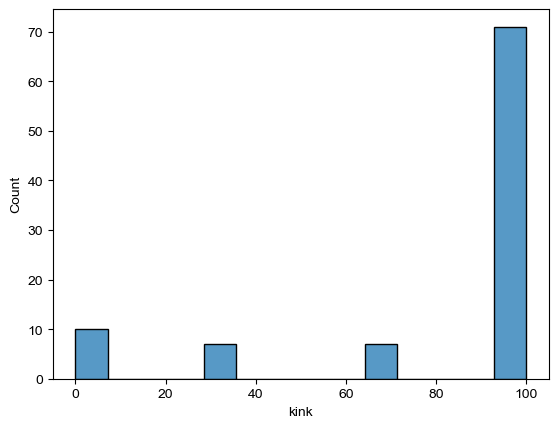

In [15]:
print((kink.kink>=100).mean())
sns.histplot(kink,x='kink')


<Axes: xlabel='unpaired_correct', ylabel='Count'>

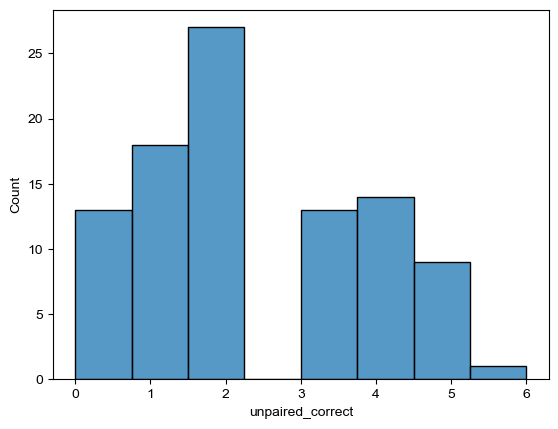

In [16]:
sns.histplot(rpsu_full,x='unpaired_correct')

In [17]:
(rpsu_full.unpaired_correct<=2).mean()

np.float64(0.6105263157894737)

In [18]:
native_interactions

{('0:100 0:101 A P', 'stacks'),
 ("0:100 0:149  O2'  N2", 'other_contacts'),
 ('0:100 1:148 W W C', 'base_pairs'),
 ('0:101 0:102 A P', 'stacks'),
 ('0:101 1:148 B A', 'stacks'),
 ('0:102 0:103 A P', 'stacks'),
 ('0:102 0:202 S W T', 'base_pairs'),
 ('0:122 0:123 A P', 'stacks'),
 ('0:123 0:176 A P', 'stacks'),
 ('0:147 1:202 B A', 'stacks'),
 ('0:148 0:149 A P', 'stacks'),
 ('0:148 1:100 W W C', 'base_pairs'),
 ('0:148 1:101 B A', 'stacks'),
 ('0:149 0:150 A P', 'stacks'),
 ('0:149 1:98 W W C', 'base_pairs'),
 ('0:150 0:151 A P', 'stacks'),
 ('0:150 1:97 W W C', 'base_pairs'),
 ('0:151 1:97 B A', 'stacks'),
 ('0:176 0:177 A P', 'stacks'),
 ('0:179 0:180 A P', 'stacks'),
 ('0:179 0:226 H W T', 'base_pairs'),
 ('0:202 0:203 A P', 'stacks'),
 ('0:202 1:147 B A', 'stacks'),
 ('0:315 1:318 W W C', 'base_pairs'),
 ('0:316 1:317 W W C', 'base_pairs'),
 ('0:317 1:316 W W C', 'base_pairs'),
 ('0:318 1:315 W W C', 'base_pairs'),
 ('0:35 0:361 B P', 'stacks'),
 ('0:35 1:45 A P', 'stacks'),
 ('0:

In [21]:
df_monomer = pd.read_csv('../../NA_CASP_assessment/raw_scores/RNA_monomer_results_table.csv')
MULTIMER_METRICS = {'lddt':'max','tm_score':'max','gdt_ts':'max',
           'TM_align':'max',
          'global_rmsd':'min','clashes_number':'min',
                   'ICS(F1)':max, 
                    'Prec.Iface':max, 
                    'Recal.Iface':max, 
                    'IPS':max, 
                    'QSglob':max, 
                    'QSbest':max, 
                    'ilDDT':max, 
                    'GlobDockQ':max, 
                    'BestDockQ':max}
# read the group information
gr_dict = pd.read_csv('../../NA_CASP_assessment/raw_scores/CASP16_Groups.csv')
gr_dict['gr_code'] = gr_dict['Group number'].apply(lambda x: '0'*(3-len(str(x)))+str(x))
gr_dict['final_name'] = gr_dict.apply(lambda x: x['Group Name'] + ' - ' + x['gr_code'], axis=1)
gr_code_to_name = gr_dict.set_index('gr_code').final_name.to_dict()
gr_dict = gr_dict.set_index('gr_code')['Group Name'].to_dict()
df_mutlimer = pd.read_csv('../../NA_CASP_assessment/raw_scores/RNA_multimer_results_table.csv',
                 delim_whitespace=True,
                 usecols=range(21),
                na_values=['-'],
                index_col=False)

col_rename = {'#Model':'model','Gr.Code':'gr_code',
'RMSD':'global_rmsd','lDDT':'lddt',  
 'TMscore':'tm_score','GDT_TS':'gdt_ts',  
'MDL.Clash':'clashes_number','TMalign':'TM_align'}
df_mutlimer.rename(columns=col_rename,inplace=True)
df_mutlimer['target'] = df_mutlimer.model.apply(lambda x: x.split('TS')[0])
df_mutlimer=df_mutlimer.astype({z:float for z in MULTIMER_METRICS.keys()})
df_mutlimer['gr_code'] = df_mutlimer.gr_code.apply(lambda x: x[:-1] if 's' in x else x)

df_mutlimer['gr_code_'] = df_mutlimer.gr_code.copy()
df_mutlimer['gr_code'] = df_mutlimer.gr_code.apply(lambda x: gr_dict[x] + ' - ' + x if x in gr_dict else x)

df_monomer = df_monomer[df_monomer.target=='R1285']
df_mutlimer = df_mutlimer[df_mutlimer.target=='R1285']

df_mutlimer.head()

C:\Users\racha\AppData\Local\Temp\ipykernel_15440\826988009.py:20: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  df_mutlimer = pd.read_csv('../../NA_CASP_assessment/raw_scores/RNA_multimer_results_table.csv',


,model,gr_code,ICS(F1),Prec.Iface,Recal.Iface,IPS,QSglob,QSbest,lddt,ilDDT,...,TM_align,GlobDockQ,BestDockQ,Mol.Size,Stoich.,MDL.Conts,REF.Conts,clashes_number,target,gr_code_
1262,R1285TS189_4o,LCBio - 189,0.444,0.500,0.400,0.532,0.231,0.346,0.567,0.297,...,0.685,0.176,0.176,2,A2,46,45,69.0,R1285,189
1263,R1285TS028_5o,NKRNA-s - 028,0.442,0.531,0.378,0.409,0.096,0.446,0.551,0.233,...,0.690,0.206,0.206,2,A2,140,45,124.0,R1285,028
1264,R1285TS286_4o,CSSB_experimental - 286,0.424,0.667,0.311,0.405,0.096,0.238,0.551,0.226,...,0.641,0.143,0.143,2,A2,52,45,0.0,R1285,286
1265,R1285TS028_4o,NKRNA-s - 028,0.414,0.429,0.400,0.463,0.097,0.419,0.572,0.250,...,0.724,0.188,0.188,2,A2,184,45,272.0,R1285,028
1266,R1285TS189_5o,LCBio - 189,0.353,0.375,0.333,0.400,0.141,0.215,0.538,0.231,...,0.434,0.127,0.127,2,A2,57,45,96.0,R1285,189


In [22]:

multimer_cols = ['model','ICS(F1)',  'IPS',
       'ilDDT', 'gdt_ts', #'global_rmsd','Prec.Iface', 'Recal.Iface', 'QSglob', 'QSbest',  'TM_align', 'GlobDockQ', 'BestDockQ'
       'tm_score','lddt']
monomer_cols = ['model' ,'lddt', 'lddt_no_checks', 'tm_score',#,'global_rmsd',
       'TM_align', 'gdt_ts', 'inf_all', 'inf_stack', 'inf_wc', 'inf_nwc']
for col in monomer_cols[1:]:
    df_monomer[col] = df_monomer[col]*100
for col in multimer_cols[1:]:
    df_mutlimer[col] = df_mutlimer[col]*100
df_monomer['model'] = df_monomer.model + 'o'

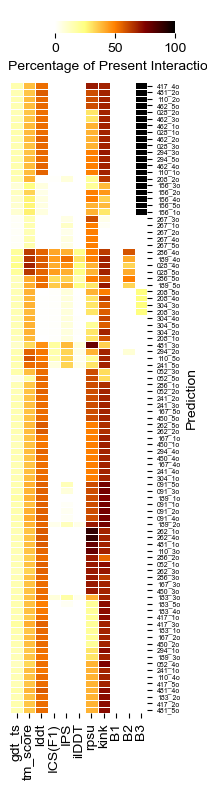

In [23]:


# Load the data of intermolecular interactions only
df = pd.read_csv("interaction_results.csv")
df = df[(df.residue.str.contains('0:'))&(df.residue.str.contains('1:'))]
df2 = pd.read_csv("interaction_results.csv")
df2 = df2[df2.motif=='kink']
df = pd.concat([df2,df])


# Calculate percentage of present interactions for each motif in each prediction
result_df = df.groupby(["prediction", "motif"])["present"].agg(["sum", "count"])
result_df["percentage"] = (result_df["sum"] / result_df["count"]) * 100

# Pivot the data for the heatmap
heatmap_data = result_df["percentage"].unstack()
#Calculate overall success and sort

heatmap_data = pd.merge(rpsu, heatmap_data, on='prediction', how='right').set_index('prediction')

heatmap_data.index = heatmap_data.index.str[:-4]
heatmap_data = pd.merge( heatmap_data, df_mutlimer[multimer_cols], right_on='model', left_on='prediction', how='left').set_index('model')
# monomer score look same as the multimer so just don't show
# heatmap_data = pd.merge( heatmap_data, df_monomer[monomer_cols], right_on='model', left_on='model', how='left').set_index('model')
overall_success = heatmap_data.sum(axis=1)
desired_order = ['gdt_ts', 
       'tm_score','lddt','ICS(F1)',  'IPS',
       'ilDDT', 'rpsu', 'kink', 'B1', 'B2', 'B3']
heatmap_data = heatmap_data[desired_order]
heatmap_data = heatmap_data.loc[overall_success.sort_values(ascending=False).index]

#Create Heatmap
g = sns.clustermap(heatmap_data, annot=False, linewidths=0.5,
                cmap='afmhot_r',  
                   cbar_kws={'orientation': 'horizontal', 'label': 'Percentage of Present Interactions', 'shrink': 0.5,'aspect': 0.2},
                   col_cluster=False,dendrogram_ratio=(0, .1),
                  figsize=(3, 8))

ax = g.ax_heatmap
# ax.set_xlabel("Motif")
ax.set_ylabel("Prediction")
cbar = ax.collections[0].colorbar
cbar_ax = cbar.ax
cbar_ax.set_aspect(10)
cbar_ax.set_position([0.2,0.95,0.4,0.02], which='original')
# Manually set y-tick labels to show all rows
ax.set_yticks([x+0.5 for x in range(len(heatmap_data))]) #Set the positions for each tick

row_order = g.dendrogram_row.reordered_ind
reordered_heatmap_data = heatmap_data.iloc[row_order]
t=ax.set_yticklabels(reordered_heatmap_data.index.str[7:], rotation=0, fontsize=5) #Set the label for each tick
plt.savefig("ole_metrics.svg",dpi=400, bbox_inches='tight', transparent=True)


In [25]:
for col in heatmap_data.columns:
    display(heatmap_data.sort_values(col,ascending=False).head())
# gdt-ts, tmscore,  R1285TS028_4o
# lddt R1285TS262_2o R1285TS262_5o next R1285TS028_4o R1285TS481_1o (57.4 v 57.2)

# ICS  IPS ilDDT R1285TS189_4o
'''
R1285o/R1285TS028_4o.pdb R1285o/R1285TS262_2o.pdb R1285o/R1285TS262_5o.pdb R1285o/R1285TS481_1o.pdb R1285o/R1285TS189_4o.pdb R1285o/R1285TS262_4o.pdb R1285o/R1285TS262_1o.pdb R1285o/R1285TS286_4o.pdb R1285o/R1285TS481_3o.pdbR1285o/R1285TS110_3o.pdb R1285o/R1285TS189_2o.pdb R1285o/R1285TS091_?o.pdb

#B3
R1285o/R1285TS417_4o.pdb R1285o/R1285TS481_2o.pdb R1285o/R1285TS110_2o.pdb 
R1285o/R1285TS462_5o.pdb R1285o/R1285TS462_4o.pdb R1285o/R1285TS110_1o.pdb
R1285o/R1285TS294_3o.pdb R1285o/R1285TS294_5o.pdb R1285o/R1285TS462_2o.pdb 
R1285o/R1285TS462_1o.pdb R1285o/R1285TS028_1o.pdb R1285o/R1285TS028_3o.pdb 
R1285o/R1285TS028_2o.pdb R1285o/R1285TS462_3o.pdb R1285o/R1285TS208_2o.pdb 
R1285o/R1285TS156_2o.pdb R1285o/R1285TS156_?o.pdb 
'''
# rpsu  R1285TS262_4o  R1285TS262_1o tons 80
# kink tos 77.272727
# B1 all 0....
# B2 R1285TS286_4o
# B3 tons 100

#-->028_4  global
#-->189_4  lddt
#-->286_4  B2

#rpsu
['R1285TS481_3o',
 'R1285TS262_1o',
 'R1285TS262_4o',
 'R1285TS481_1o',
 'R1285TS110_3o']

#kink
['R1285TS189_2o',
 'R1285TS091_5o',
 'R1285TS091_3o',
 'R1285TS091_2o',
 'R1285TS091_4o',
 'R1285TS091_1o']


# b3
['R1285TS417_4o',
 'R1285TS481_2o',
 'R1285TS110_2o',
 'R1285TS462_5o',
 'R1285TS462_4o',
 'R1285TS110_1o',
 'R1285TS294_3o',
 'R1285TS294_5o',
 'R1285TS462_2o',
 'R1285TS462_1o',
 'R1285TS028_1o',
 'R1285TS028_3o',
 'R1285TS028_2o',
 'R1285TS462_3o',
 'R1285TS208_2o',
 'R1285TS156_2o',
 'R1285TS156_4o',
 'R1285TS156_5o',
 'R1285TS156_1o',
 'R1285TS156_3o']

,gdt_ts,tm_score,lddt,ICS(F1),IPS,ilDDT,rpsu,kink,B1,B2,B3
model,,,,,,,,,,,
R1285TS028_4o,23.2,68.2,57.2,41.4,46.3,25.0,40.0,68.181818,0.0,33.333333,0.0
R1285TS189_4o,20.7,64.6,56.7,44.4,53.2,29.7,50.0,68.181818,0.0,41.666667,0.0
R1285TS286_4o,19.8,62.9,55.1,42.4,40.5,22.6,50.0,63.636364,0.0,58.333333,0.0
R1285TS028_5o,19.7,64.0,55.1,44.2,40.9,23.3,40.0,68.181818,0.0,41.666667,0.0
R1285TS417_3o,18.5,40.8,55.6,0.0,0.0,0.0,20.0,68.181818,0.0,0.000000,0.0


,gdt_ts,tm_score,lddt,ICS(F1),IPS,ilDDT,rpsu,kink,B1,B2,B3
model,,,,,,,,,,,
R1285TS028_4o,23.2,68.2,57.2,41.4,46.3,25.0,40.0,68.181818,0.0,33.333333,0.0
R1285TS189_4o,20.7,64.6,56.7,44.4,53.2,29.7,50.0,68.181818,0.0,41.666667,0.0
R1285TS028_5o,19.7,64.0,55.1,44.2,40.9,23.3,40.0,68.181818,0.0,41.666667,0.0
R1285TS286_4o,19.8,62.9,55.1,42.4,40.5,22.6,50.0,63.636364,0.0,58.333333,0.0
R1285TS110_5o,17.1,58.8,50.9,15.6,33.3,3.6,20.0,68.181818,0.0,0.000000,0.0


,gdt_ts,tm_score,lddt,ICS(F1),IPS,ilDDT,rpsu,kink,B1,B2,B3
model,,,,,,,,,,,
R1285TS262_2o,15.3,38.0,57.4,0.0,0.0,0.0,50.0,65.909091,0.0,0.000000,0.0
R1285TS262_5o,15.3,38.0,57.4,0.0,0.0,0.0,50.0,65.909091,0.0,0.000000,0.0
R1285TS028_4o,23.2,68.2,57.2,41.4,46.3,25.0,40.0,68.181818,0.0,33.333333,0.0
R1285TS481_1o,14.9,37.7,57.2,0.0,0.0,0.0,80.0,68.181818,0.0,0.000000,0.0
R1285TS481_4o,16.8,39.2,57.1,0.0,0.0,0.0,40.0,72.727273,0.0,0.000000,0.0


,gdt_ts,tm_score,lddt,ICS(F1),IPS,ilDDT,rpsu,kink,B1,B2,B3
model,,,,,,,,,,,
R1285TS189_4o,20.7,64.6,56.7,44.4,53.2,29.7,50.0,68.181818,0.0,41.666667,0.0
R1285TS028_5o,19.7,64.0,55.1,44.2,40.9,23.3,40.0,68.181818,0.0,41.666667,0.0
R1285TS286_4o,19.8,62.9,55.1,42.4,40.5,22.6,50.0,63.636364,0.0,58.333333,0.0
R1285TS028_4o,23.2,68.2,57.2,41.4,46.3,25.0,40.0,68.181818,0.0,33.333333,0.0
R1285TS189_5o,13.9,40.7,53.8,35.3,40.0,23.1,30.0,70.454545,0.0,33.333333,0.0


,gdt_ts,tm_score,lddt,ICS(F1),IPS,ilDDT,rpsu,kink,B1,B2,B3
model,,,,,,,,,,,
R1285TS189_4o,20.7,64.6,56.7,44.4,53.2,29.7,50.0,68.181818,0.0,41.666667,0.0
R1285TS028_4o,23.2,68.2,57.2,41.4,46.3,25.0,40.0,68.181818,0.0,33.333333,0.0
R1285TS028_5o,19.7,64.0,55.1,44.2,40.9,23.3,40.0,68.181818,0.0,41.666667,0.0
R1285TS286_4o,19.8,62.9,55.1,42.4,40.5,22.6,50.0,63.636364,0.0,58.333333,0.0
R1285TS189_5o,13.9,40.7,53.8,35.3,40.0,23.1,30.0,70.454545,0.0,33.333333,0.0


...

,gdt_ts,tm_score,lddt,ICS(F1),IPS,ilDDT,rpsu,kink,B1,B2,B3
model,,,,,,,,,,,
R1285TS091_3o,16.0,39.5,56.1,0.0,7.3,0.0,60.0,77.272727,0.0,0.0,0.0
R1285TS091_1o,16.0,37.7,56.2,0.0,1.7,0.0,60.0,77.272727,0.0,0.0,0.0
R1285TS091_4o,16.0,41.1,56.1,0.0,2.3,0.0,60.0,77.272727,0.0,0.0,0.0
R1285TS091_2o,16.2,40.6,56.1,0.0,2.9,0.0,60.0,77.272727,0.0,0.0,0.0
R1285TS189_2o,15.9,39.5,54.9,4.1,13.0,4.4,70.0,77.272727,0.0,0.0,0.0


,gdt_ts,tm_score,lddt,ICS(F1),IPS,ilDDT,rpsu,kink,B1,B2,B3
model,,,,,,,,,,,
R1285TS189_4o,20.7,64.6,56.7,44.4,53.2,29.7,50.0,68.181818,0.0,41.666667,0.0
R1285TS450_1o,14.0,37.1,51.6,0.0,0.0,0.0,50.0,69.047619,0.0,0.000000,0.0
R1285TS417_5o,14.5,36.2,53.7,0.0,0.0,0.0,40.0,68.181818,0.0,0.000000,0.0
R1285TS241_1o,15.2,37.5,51.8,0.0,0.0,0.0,40.0,68.181818,0.0,0.000000,0.0
R1285TS110_4o,14.6,36.6,53.7,0.0,0.0,0.0,40.0,68.181818,0.0,0.000000,0.0


,gdt_ts,tm_score,lddt,ICS(F1),IPS,ilDDT,rpsu,kink,B1,B2,B3
model,,,,,,,,,,,
R1285TS286_4o,19.8,62.9,55.1,42.4,40.5,22.6,50.0,63.636364,0.0,58.333333,0.0
R1285TS286_5o,13.2,41.3,53.6,31.6,34.0,15.1,50.0,59.090909,0.0,50.000000,0.0
R1285TS189_4o,20.7,64.6,56.7,44.4,53.2,29.7,50.0,68.181818,0.0,41.666667,0.0
R1285TS028_5o,19.7,64.0,55.1,44.2,40.9,23.3,40.0,68.181818,0.0,41.666667,0.0
R1285TS028_4o,23.2,68.2,57.2,41.4,46.3,25.0,40.0,68.181818,0.0,33.333333,0.0


,gdt_ts,tm_score,lddt,ICS(F1),IPS,ilDDT,rpsu,kink,B1,B2,B3
model,,,,,,,,,,,
R1285TS462_3o,14.8,36.2,53.5,0.0,0.0,0.0,30.0,68.181818,0.0,0.0,100.0
R1285TS294_3o,15.5,36.8,54.4,0.0,0.0,0.0,50.0,70.454545,0.0,0.0,100.0
R1285TS208_2o,15.0,39.1,0.4,0.9,7.2,0.3,20.0,64.285714,0.0,0.0,100.0
R1285TS156_3o,7.9,24.2,6.5,0.0,0.0,0.0,20.0,38.636364,0.0,0.0,100.0
R1285TS156_1o,9.0,28.0,6.6,0.0,0.0,0.0,40.0,29.545455,0.0,0.0,100.0


['R1285TS417_4o',
 'R1285TS481_2o',
 'R1285TS110_2o',
 'R1285TS462_5o',
 'R1285TS462_4o',
 'R1285TS110_1o',
 'R1285TS294_3o',
 'R1285TS294_5o',
 'R1285TS462_2o',
 'R1285TS462_1o',
 'R1285TS028_1o',
 'R1285TS028_3o',
 'R1285TS028_2o',
 'R1285TS462_3o',
 'R1285TS208_2o',
 'R1285TS156_2o',
 'R1285TS156_4o',
 'R1285TS156_5o',
 'R1285TS156_1o',
 'R1285TS156_3o']

In [26]:
(heatmap_data.B3==100).mean()

np.float64(0.21052631578947367)

In [27]:
6/95

0.06315789473684211

In [28]:
len(heatmap_data)

95

In [29]:
heatmap_data[heatmap_data.rpsu>=80].index.to_list()

['R1285TS481_3o',
 'R1285TS262_1o',
 'R1285TS262_4o',
 'R1285TS481_1o',
 'R1285TS110_3o']

In [30]:
heatmap_data[heatmap_data.kink>77].index.to_list()

['R1285TS189_2o',
 'R1285TS091_5o',
 'R1285TS091_3o',
 'R1285TS091_2o',
 'R1285TS091_4o',
 'R1285TS091_1o']

In [31]:
heatmap_data[heatmap_data.B3==100].index.to_list()

['R1285TS417_4o',
 'R1285TS481_2o',
 'R1285TS110_2o',
 'R1285TS462_5o',
 'R1285TS462_4o',
 'R1285TS110_1o',
 'R1285TS294_3o',
 'R1285TS294_5o',
 'R1285TS462_2o',
 'R1285TS462_1o',
 'R1285TS028_1o',
 'R1285TS028_3o',
 'R1285TS028_2o',
 'R1285TS462_3o',
 'R1285TS208_2o',
 'R1285TS156_2o',
 'R1285TS156_4o',
 'R1285TS156_5o',
 'R1285TS156_1o',
 'R1285TS156_3o']